In [1]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(cowplot)
library(stringr)

Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Loading required package: sp

‘SeuratObject’ was built with package ‘Matrix’ 1.7.2 but the current
version is 1.7.3; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”


In [2]:
reflex_so <- readRDS('seurat_objects/reflex_exp1936_so_updated.rds')
reflex_so

An object of class Seurat 
18129 features across 149597 samples within 1 assay 
Active assay: RNA (18129 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [3]:
prime5_so <- readRDS('seurat_objects/clean_donor_match_sc5p.rds')
prime5_so

An object of class Seurat 
38606 features across 16309 samples within 1 assay 
Active assay: RNA (38606 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [4]:
reflex_so$tech <- 'REFLEX'
prime5_so$tech <- "10x_5prime"

In [5]:
so <- merge(reflex_so, prime5_so)

# Clean up TCR data

In [6]:
so$CTgene_archive <- so$CTgene

In [7]:
so@meta.data <- so@meta.data %>%
  mutate(
    CTgene = str_remove_all(CTgene_archive, "\\*[A-Za-z0-9]+\\([0-9.]+\\)")
  )

In [8]:
so@meta.data <- so@meta.data %>%
  mutate(clone_type = case_when(
    # Case 1: Total NA (either the logical NA or the literal "NA" string)
    is.na(CTgene) | CTgene == "NA" ~ "No clone",
    
    # Case 2: Starts with NA_ (meaning Alpha is missing)
    str_detect(CTgene, "^NA_")     ~ "TRB",
    
    # Case 3: Ends with _NA (meaning Beta is missing)
    str_detect(CTgene, "_NA$")     ~ "TRA",
    
    # Case 4: Everything else (both parts have characters)
    TRUE                           ~ "TRA;TRB"
  ))

In [9]:
so@meta.data <- so@meta.data %>%
  mutate(
    # 1. Extract everything before the LAST underscore
    CDR3a = str_replace(CTaa, "_[^_]+$", ""),
    
    # 2. Extract everything after the LAST underscore
    CDR3b = str_extract(CTaa, "[^_]+$")
  ) %>%
  mutate(
    # 3. Clean up the literal "NA" strings to be actual R NAs
    CDR3a = ifelse(CDR3a == "NA", NA_character_, CDR3a),
    CDR3b = ifelse(CDR3b == "NA", NA_character_, CDR3b)
  )

# UMAP integration

In [ ]:
# run standard anlaysis workflow
so <- NormalizeData(so)
so <- FindVariableFeatures(so)
so <- ScaleData(so)
so <- RunPCA(so)

Normalizing layer: counts.SeuratProject

Normalizing layer: counts.10x_5prime_Donor_Match

Finding variable features for layer counts.SeuratProject

Finding variable features for layer counts.10x_5prime_Donor_Match

Centering and scaling data matrix



In [ ]:
so <- IntegrateLayers(object = so, method = CCAIntegration, orig.reduction = "pca", new.reduction = "integrated.cca",
    verbose = FALSE)

# re-join layers after integration
so[["RNA"]] <- JoinLayers(so[["RNA"]])

so <- FindNeighbors(so, reduction = "integrated.cca", dims = 1:30)
so <- FindClusters(so, resolution = 1)

In [ ]:
so <- RunUMAP(so, dims = 1:30, reduction = "integrated.cca")

In [ ]:
so

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



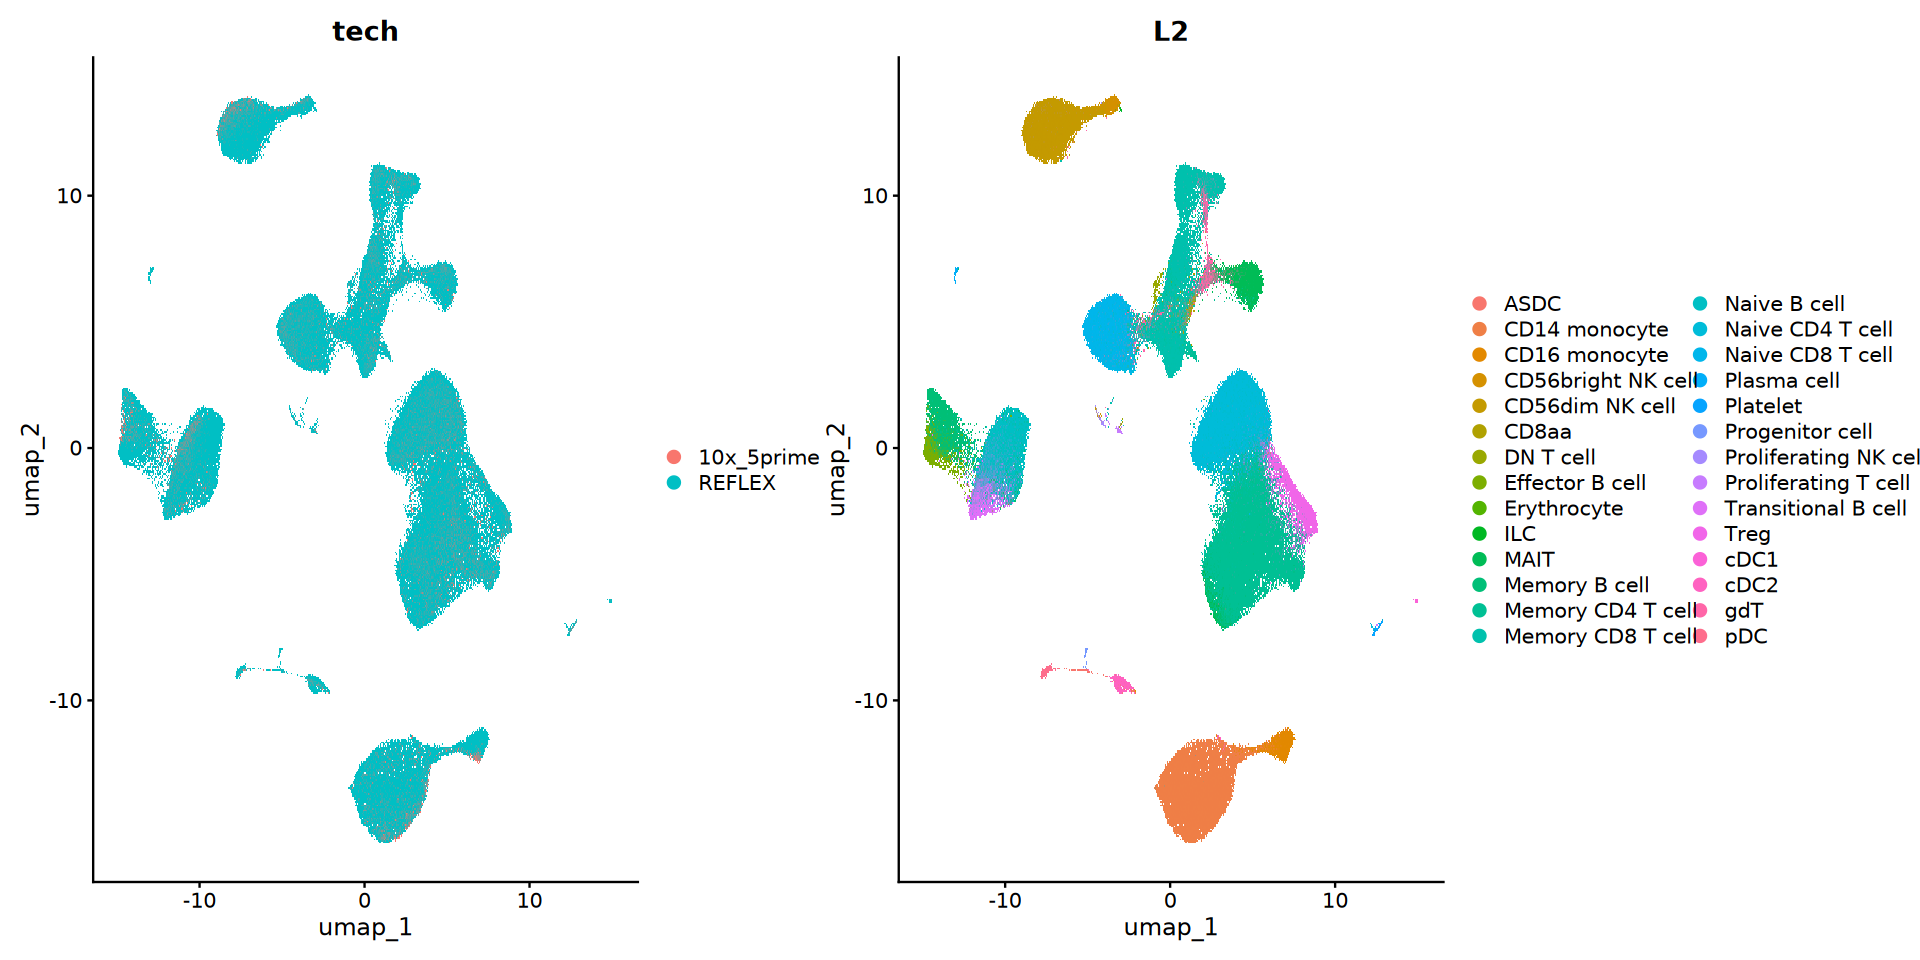

In [17]:
options(repr.plot.width = 16, repr.plot.height = 8)
DimPlot(so, reduction = "umap", group.by = c("tech", "L2"), shuffle = TRUE)

In [ ]:
saveRDS(so, 'seurat_objects/integrated_so.rds')

In [ ]:
sessionInfo()